In [2]:
import numpy as np
import pandas as pd
import matplotlib

from matplotlib import pyplot as plt
# Graphics in SVG format are more sharp and legible
%config InlineBackend.figure_format = 'svg'
pd.set_option("display.precision", 2)

In [6]:
data = pd.read_csv('titanic_train.csv', index_col='PassengerId')
data.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S


In [7]:
data.describe()

data[(data['Embarked'] == 'C') & (data.Fare > 200)].head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.52,B58 B60,C
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.33,NaN,C
300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.52,B58 B60,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.38,B57 B59 B63 B66,C
378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.50,C82,C


In [8]:
data.describe()

data[(data['Embarked'] == 'C') & 
     (data.Fare > 200)].sort_values(by='Fare', ascending=False).head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.33,NaN,C
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.33,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.33,B101,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.38,B57 B59 B63 B66,C
743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.38,B57 B59 B63 B66,C


In [9]:
def age_category(age):
    if age < 30:
        return 1
    elif age < 55:
        return 2
    elif age >= 55:
        return 3

In [10]:
age_categories = [age_category(age) for age in data.Age]
data['Age_category'] = age_categories
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_category
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1.0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,2.0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,1.0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,2.0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,2.0


In [11]:
data['Age_category'] = data['Age'].apply(age_category)
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_category
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1.0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,2.0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.92,NaN,S,1.0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,2.0
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,2.0


**1. Сколько мужчин / женщин было на борту?**
- 412 мужчин и 479 женщин
- 314 мужчин и 577 женщин
- 479 мужчин и 412 женщин
- 577 мужчин и 314 женщин

In [19]:
male = len(data[data['Sex'] == 'male'])
female = len(data[data['Sex'] == 'female'])

print(f'{male} мужчин и {female} женщин')

print(data.Sex.eq('male').sum())
print(len(data.query('Sex == "male"')))

577 мужчин и 314 женщин
577
577


**2. Определите распределение функции `Pclass`. Теперь Для мужчин и женщин отдельно. Сколько людей из второго класса было на борту?**
- 104
- 108
- 112
- 125

In [20]:
data['Pclass'].notnull().sum()
data['Pclass'].eq(2).sum()
# data.head()


184

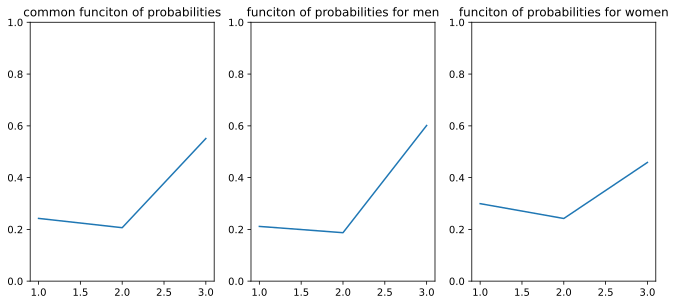

In [22]:
classes = data['Pclass'].unique()
classes.sort()

def count_probabilities(sex):
    dict = {}
    total_person = data['Sex'].eq(sex).sum()
    for clas in classes:
        dict[clas] = len(data[(data.Pclass == clas) 
                              & (data.Sex == sex)]) / total_person
    return dict

men = count_probabilities('male')
women = count_probabilities('female')

common = {}
total_person = data['Pclass'].notnull().sum()
for clas in classes:
    common[clas] = data['Pclass'].eq(clas).sum() / total_person

plt.subplot(1,3,1)
plt.plot(list(common.keys()), list(common.values()))
plt.title('common funciton of probabilities')
plt.ylim(0, 1)   # set the ylim to bottom, top

plt.subplot(1,3,2)
plt.plot(list(men.keys()), list(men.values()))
plt.title('funciton of probabilities for men')
plt.ylim(0, 1)   # set the ylim to bottom, top

plt.subplot(1,3,3)
plt.plot(list(women.keys()), list(women.values()))
plt.title('funciton of probabilities for women')
plt.ylim(0, 1)   # set the ylim to bottom, top

plt.rcParams["figure.autolayout"] = False

plt.subplots_adjust(left=0.1,
                    bottom=1, 
                    right=1.55, 
                    top=1.9)


plt.show()



In [23]:
# data[data.Pclass==1].sum()
tm = data[(data['Pclass'].notnull() == 1)]
data['Sex'].eq('male').sum()

# data[data['Pclass'] == 1 & data['Sex'] == "male"]

577